# Transformada de Hilbert — Aplicações em Telecomunicações Digitais e Processamento de Voz


A Transformada de Hilbert é amplamente utilizada em:

- telecomunicações digitais;
- modulações AM/FM/SSB/QAM;
- sistemas I/Q;
- rádio definido por software (SDR);
- processamento de voz;
- análise biomédica;
- radar e sonar.

Sua principal função é produzir uma versão do sinal com deslocamento de fase de 90°.

A partir dela, podemos construir o chamado **sinal analítico**.

---

Para um sinal real $x(t)$, a Transformada de Hilbert produz:

$$
\hat{x}(t)
$$

que representa o mesmo sinal deslocado em fase.

No domínio da frequência:

- frequências positivas → deslocamento de $-90^\circ$
- frequências negativas → deslocamento de $+90^\circ$

---

O sinal analítico é definido por:

$$
x_a(t)=x(t)+j\hat{x}(t)
$$

onde:

- parte real → sinal original;
- parte imaginária → Transformada de Hilbert.

Isso permite extrair:

- envelope;
- fase instantânea;
- frequência instantânea.

---

# Demodulação AM

Na modulação AM:

$$
s(t)=A_c(1+m(t))\cos(2\pi f_ct)
$$

O envelope do sinal contém a mensagem original.

A Transformada de Hilbert permite obter esse envelope usando:

$$
A(t)=\sqrt{x^2(t)+\hat{x}^2(t)}
$$

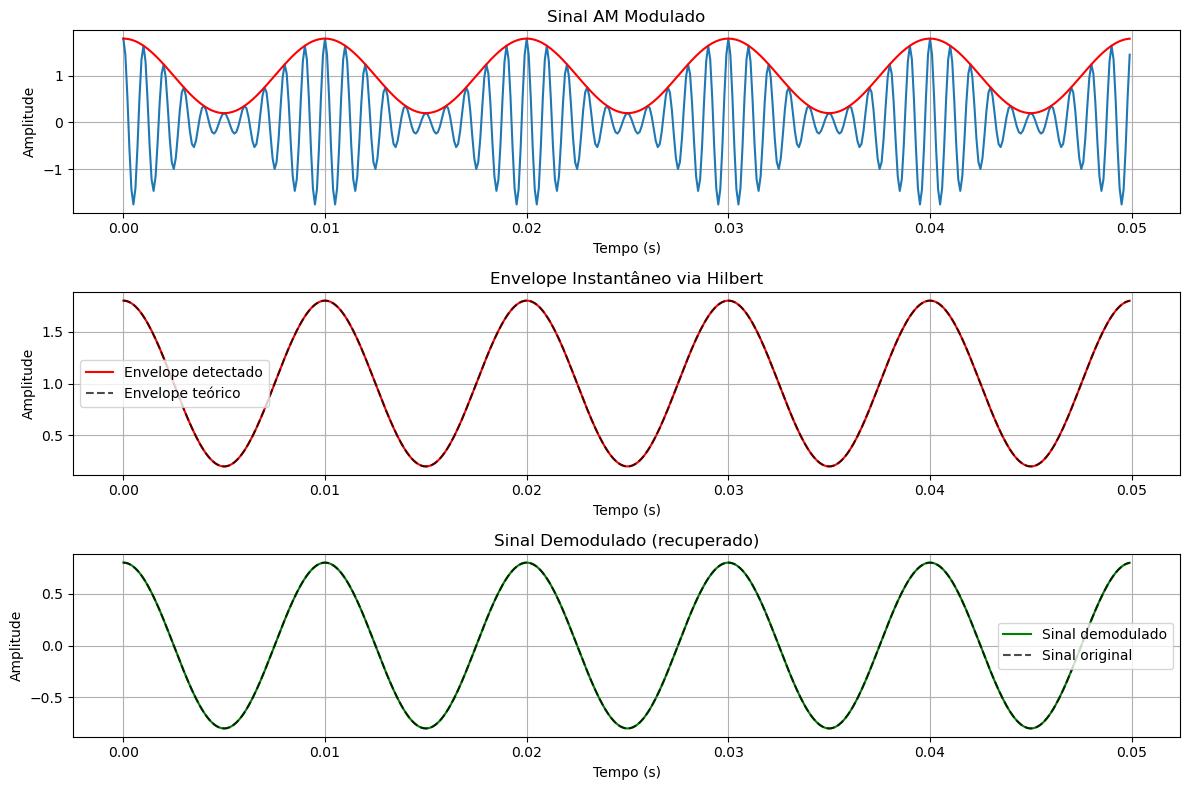

SNR de demodulação: 275.78 dB


In [ ]:
"""
Script 1: Demodulação de AM usando Transformada de Hilbert
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Parâmetros
fs = 10000  # Taxa de amostragem (Hz)
fc = 1000   # Frequência da portadora (Hz)
fm = 100    # Frequência do sinal modulante (Hz)
t = np.arange(0, 0.05, 1/fs)  # 50ms

# Sinal modulante (mensagem)
m = 0.8 * np.cos(2 * np.pi * fm * t)  # Índice de modulação 0.8

# Sinal AM
carrier = np.cos(2 * np.pi * fc * t)
x_am = (1 + m) * carrier

# Demodulação via Hilbert
analytic_signal = hilbert(x_am)
envelope = np.abs(analytic_signal)
demodulado = envelope - 1  # Remove o offset DC

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8))

axs[0].plot(t, x_am)
axs[0].plot(t, envelope, 'r')
axs[0].set_title('Sinal AM Modulado')
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

axs[1].plot(t, envelope, 'r', label='Envelope detectado')
axs[1].plot(t, 1 + m, 'k--', label='Envelope teórico', alpha=0.7)
axs[1].set_title('Envelope Instantâneo via Hilbert')
axs[1].set_xlabel('Tempo (s)')
axs[1].set_ylabel('Amplitude')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t, demodulado, 'g', label='Sinal demodulado')
axs[2].plot(t, m, 'k--', label='Sinal original', alpha=0.7)
axs[2].set_title('Sinal Demodulado (recuperado)')
axs[2].set_xlabel('Tempo (s)')
axs[2].set_ylabel('Amplitude')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

print(f"SNR de demodulação: {20*np.log10(np.std(m)/np.std(m-demodulado)):.2f} dB")

# Demodulação FM

Em FM, a informação está na frequência instantânea.

A partir do sinal analítico:

$$
\phi(t)=\tan^{-1}\left(\frac{\hat{x}(t)}{x(t)}\right)
$$

A frequência instantânea é:

$$
f_i(t)=\frac{1}{2\pi}\frac{d\phi(t)}{dt}
$$

-----

- Sinal FM: $x(t) = A \cos\left(2\pi f_c t + \phi(t)\right)$.
- Fase instantânea: $\phi(t) = \arg\left(x(t) + j\hat{x}(t)\right)$.
- Frequência instantânea: $f_i(t) = \frac{1}{2\pi} \frac{d\phi(t)}{dt}$.
- Permite demodular FM sem usar PLL.

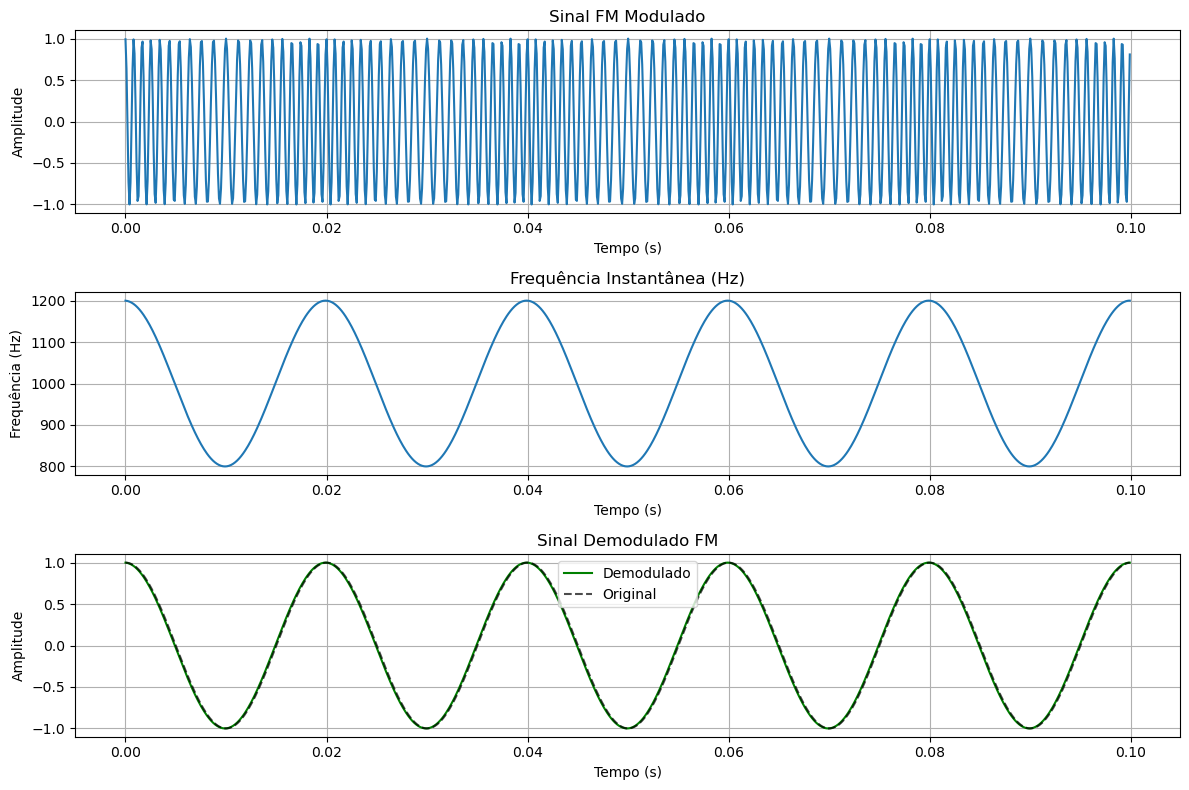

Erro médio de demodulação: 0.0200


In [ ]:
"""
Demodulação de FM usando Transformada de Hilbert
"""

# Parâmetros
fs = 10000
fc = 1000      # Frequência da portadora
fd = 200       # Desvio de frequência
fm = 50        # Frequência do sinal modulante
t = np.arange(0, 0.1, 1/fs)

# Sinal modulante
m = np.cos(2 * np.pi * fm * t)

# Sinal FM: x(t) = cos(2πfc t + 2πfd ∫m(τ)dτ)
phi = 2 * np.pi * fd * np.cumsum(m) / fs  # Integral acumulada
x_fm = np.cos(2 * np.pi * fc * t + phi)

# Demodulação via Hilbert
analytic = hilbert(x_fm)
fase_instantanea = np.unwrap(np.angle(analytic))
frequencia_instantanea = np.diff(fase_instantanea) * fs / (2 * np.pi)

# Ajustar tamanhos
frequencia_instantanea = np.append(frequencia_instantanea, frequencia_instantanea[-1])
demodulado_fm = (frequencia_instantanea - fc) / fd  # Normalizado

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8))

axs[0].plot(t, x_fm)
axs[0].set_title('Sinal FM Modulado')
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

axs[1].plot(t, frequencia_instantanea)
axs[1].set_title('Frequência Instantânea (Hz)')
axs[1].set_xlabel('Tempo (s)')
axs[1].set_ylabel('Frequência (Hz)')
axs[1].grid(True)

axs[2].plot(t, demodulado_fm, 'g', label='Demodulado')
axs[2].plot(t, m, 'k--', label='Original', alpha=0.7)
axs[2].set_title('Sinal Demodulado FM')
axs[2].set_xlabel('Tempo (s)')
axs[2].set_ylabel('Amplitude')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Erro médio de demodulação: {np.mean(np.abs(m - demodulado_fm)):.4f}")

# Demodulação de SSB (Single Sideband)

SSB elimina uma das bandas laterais da AM.

Isso reduz:

- largura de banda;
- potência transmitida.

A Transformada de Hilbert gera um deslocamento de fase necessário para cancelar uma das bandas.

Equação:

$$
s_{SSB}(t)=x(t)\cos(\omega_ct)-\hat{x}(t)\sin(\omega_ct)
$$

----

- Sinal SSB: $x(t) = m(t) \cos(2\pi f_c t) \pm \hat{m}(t) \sin(2\pi f_c t)$.
- Demodulação: multiplica-se por $\cos(2\pi f_c t)$ e aplica-se filtro passa-baixas.

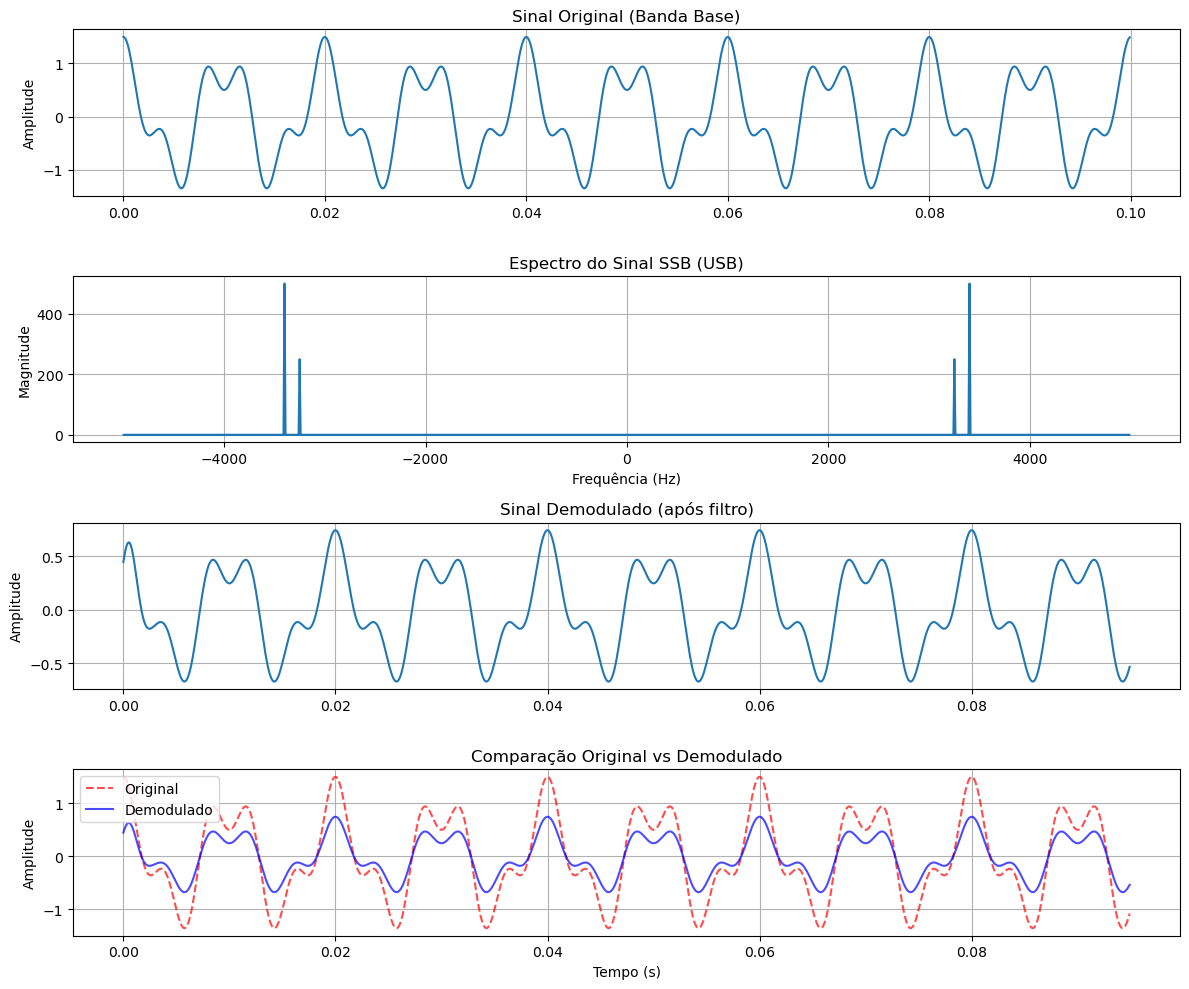

In [ ]:
"""
Geração e Demodulação de SSB (USB) usando Hilbert
"""
from scipy.signal import firwin, lfilter

# Parâmetros
fs = 10000
fc = 1500      # Frequência da portadora
f1, f2 = 100, 250  # Frequências do sinal de teste
t = np.arange(0, 0.1, 1/fs)

# Sinal de mensagem (banda base)
m = np.cos(2 * np.pi * f1 * t) + 0.5 * np.cos(2 * np.pi * f2 * t)

# Gerar SSB (USB - Upper Sideband)
m_hilbert = np.imag(hilbert(m))  # Transformada de Hilbert
x_ssb = m * np.cos(2 * np.pi * fc * t) - m_hilbert * np.sin(2 * np.pi * fc * t)

# Demodulação SSB (multiplicar por portadora e filtrar)
demodulado_bruto = x_ssb * np.cos(2 * np.pi * fc * t)

# Filtro passa-baixas para recuperar mensagem
nyquist = fs / 2
cutoff = 500  # Hz
numtaps = 101
h = firwin(numtaps, cutoff / nyquist, window='hamming')
demodulado = lfilter(h, 1, demodulado_bruto)

# Delay do filtro (compensação)
demodulado = demodulado[numtaps//2:]

fig, axs = plt.subplots(4, 1, figsize=(12, 10))

axs[0].plot(t, m)
axs[0].set_title('Sinal Original (Banda Base)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# Espectro
freqs = np.fft.fftfreq(len(x_ssb), 1/fs)
X_ssb = np.fft.fftshift(np.abs(np.fft.fft(x_ssb)))
axs[1].plot(freqs, X_ssb)
axs[1].set_title('Espectro do Sinal SSB (USB)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude')
axs[1].grid(True)

axs[2].plot(t[:len(demodulado)], demodulado)
axs[2].set_title('Sinal Demodulado (após filtro)')
axs[2].set_ylabel('Amplitude')
axs[2].grid(True)

axs[3].plot(t[:len(demodulado)], m[:len(demodulado)], 'r--', alpha=0.7, label='Original')
axs[3].plot(t[:len(demodulado)], demodulado, 'b-', alpha=0.7, label='Demodulado')
axs[3].set_title('Comparação Original vs Demodulado')
axs[3].set_xlabel('Tempo (s)')
axs[3].set_ylabel('Amplitude')
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()

# Modulações Digitais

Em sistemas digitais, a TH é essencial para representar sinais em banda base complexa.

### a) Geração e Demodulação de QAM
- Sinal QAM: $s(t) = I(t) \cos(2\pi f_c t) - Q(t) \sin(2\pi f_c t)$.
- Representação analítica: $s_a(t) = (I(t) + jQ(t)) e^{j2\pi f_c t}$.

### b) Modulação BPSK, QPSK e MSK
- **BPSK**: $A \cos(2\pi f_c t + \theta_i)$ – recuperação de fase via TH.
- **MSK**: Uso de pulsos senoidais na fase e quadratura.

### c) Estimação de Frequência e Fase de Portadora
- Cálculo da derivada da fase para estimar *offset* de portadora.

MSE: 0.006014
Símbolos corretos: 128/128


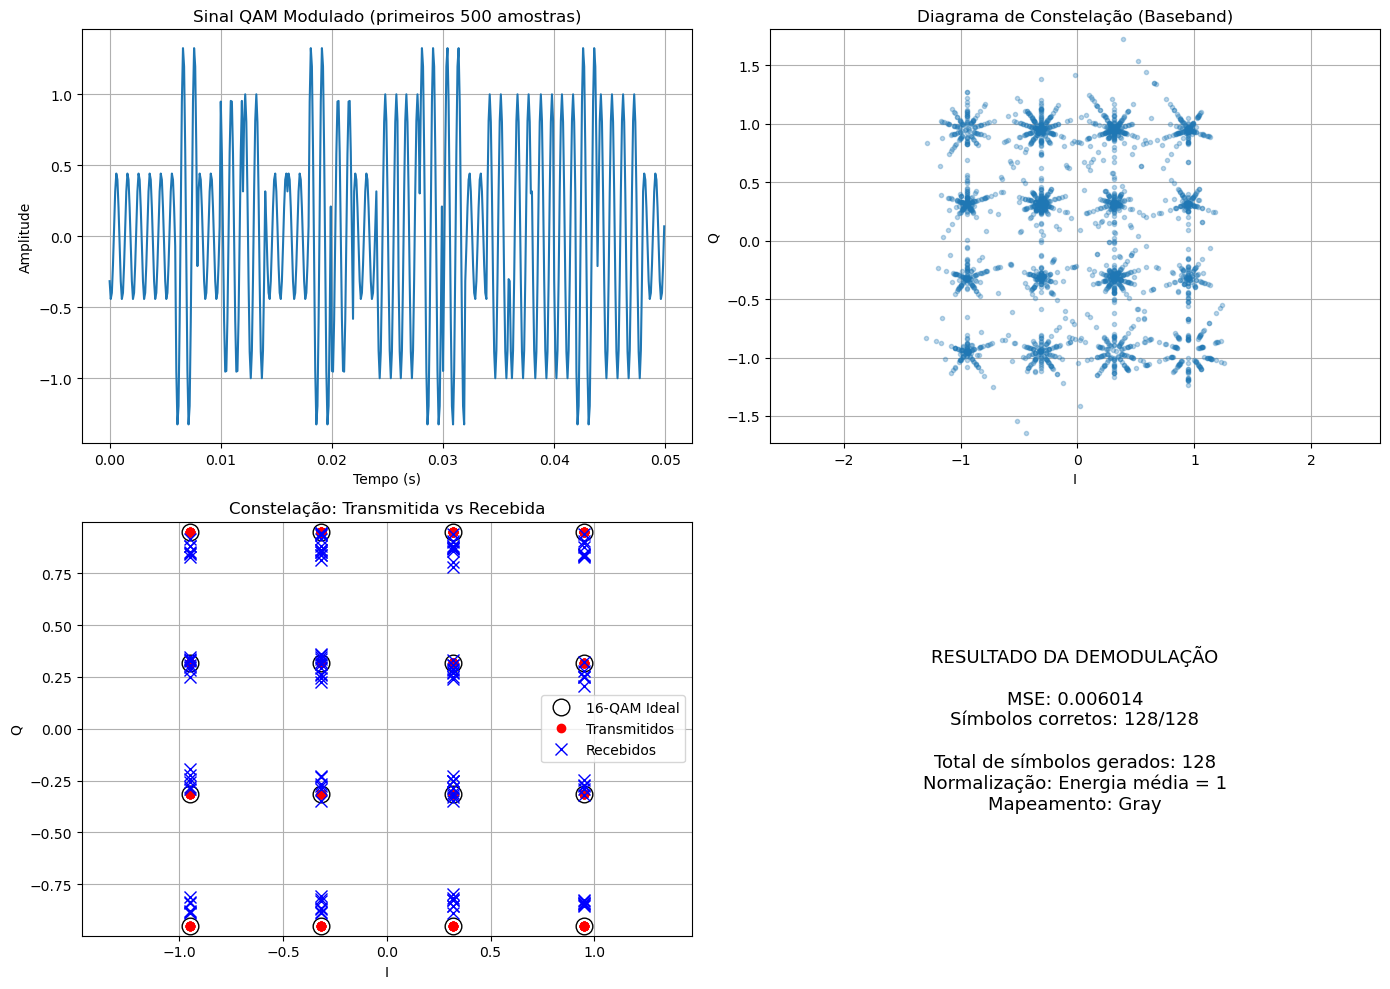

In [38]:
"""
16-QAM - Geração, Modulação e Demodulação com Hilbert Transform
Versão Melhorada e Didática
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert


fs = 10000                  # Frequência de amostragem
fc = 1000                   # Frequência da portadora
symbol_rate = 500           # Taxa de símbolos por segundo
samples_per_symbol = fs // symbol_rate
n_symbols = 128             # Número de símbolos (aumentado para ver todos os pontos)

# Pontos originais (antes da normalização)
points = np.array([-3-3j, -3-1j, -3+1j, -3+3j,
                   -1-3j, -1-1j, -1+1j, -1+3j,
                    1-3j,  1-1j,  1+1j,  1+3j,
                    3-3j,  3-1j,  3+1j,  3+3j])

# Gray Mapping
gray_order = [0, 1, 3, 2, 6, 7, 5, 4, 12, 13, 15, 14, 10, 11, 9, 8]
constellation = points[gray_order]

# Normalização (energia média = 1)
constellation = constellation / np.sqrt(np.mean(np.abs(constellation)**2))

# GERAÇÃO DE SÍMBOLOS
np.random.seed(42)  # Reprodutibilidade
bits = np.random.randint(0, 2, n_symbols * 4)

symbols = []
for i in range(n_symbols):
    idx = int(''.join(map(str, bits[i*4:(i+1)*4])), 2)
    symbols.append(constellation[idx])
symbols = np.array(symbols)

#  MODULAÇÃO
# Upsampling (pulso retangular)
I_up = np.repeat(np.real(symbols), samples_per_symbol)
Q_up = np.repeat(np.imag(symbols), samples_per_symbol)
t = np.arange(len(I_up)) / fs

# Sinal modulado QAM
x_qam = I_up * np.cos(2 * np.pi * fc * t) - Q_up * np.sin(2 * np.pi * fc * t)

#  DEMODULAÇÃO COM HILBERT 
analytic = hilbert(x_qam)
baseband = analytic * np.exp(-1j * 2 * np.pi * fc * t)

# Amostragem no centro de cada símbolo
offset = samples_per_symbol // 2
received_symbols = baseband[offset::samples_per_symbol][:n_symbols]

#  CÁLCULO DE ERRO 
mse = np.mean(np.abs(symbols - received_symbols)**2)
correct = np.sum(np.abs(symbols - received_symbols) < 0.4)

print(f"MSE: {mse:.6f}")
print(f"Símbolos corretos: {correct}/{n_symbols}")

#  PLOTS 
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sinal modulado no tempo
axs[0, 0].plot(t[:500], x_qam[:500])
axs[0, 0].set_title('Sinal QAM Modulado (primeiros 500 amostras)')
axs[0, 0].set_xlabel('Tempo (s)')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].grid(True)

# 2. Constelação Baseband (antes da amostragem)
axs[0, 1].plot(np.real(baseband), np.imag(baseband), '.', alpha=0.3, label='Baseband')
axs[0, 1].set_title('Diagrama de Constelação (Baseband)')
axs[0, 1].set_xlabel('I')
axs[0, 1].set_ylabel('Q')
axs[0, 1].grid(True)
axs[0, 1].axis('equal')

# 3. Constelação Transmitida vs Recebida
axs[1, 0].plot(np.real(constellation), np.imag(constellation), 'ko', markersize=12, 
               fillstyle='none', label='16-QAM Ideal')
axs[1, 0].plot(np.real(symbols), np.imag(symbols), 'ro', markersize=6, label='Transmitidos')
axs[1, 0].plot(np.real(received_symbols), np.imag(received_symbols), 'bx', markersize=8, label='Recebidos')
axs[1, 0].set_title('Constelação: Transmitida vs Recebida')
axs[1, 0].set_xlabel('I')
axs[1, 0].set_ylabel('Q')
axs[1, 0].legend()
axs[1, 0].grid(True)
axs[1, 0].axis('equal')

# 4. Resultados
axs[1, 1].axis('off')
text = f"""RESULTADO DA DEMODULAÇÃO
\nMSE: {mse:.6f}
Símbolos corretos: {correct}/{n_symbols}
\nTotal de símbolos gerados: {n_symbols}
Normalização: Energia média = 1
Mapeamento: Gray"""
axs[1, 1].text(0.5, 0.5, text, horizontalalignment='center', 
               verticalalignment='center', fontsize=13, transform=axs[1, 1].transAxes)

plt.tight_layout()
plt.show()